In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('datasets\\swiggy_orders.csv')
df.head()

,order_id,restaurant_name,city,category,order_value,delivery_time_mins,rating,order_date,time_slot,is_reorder,discount_applied,platform
0,101569,Sweet Truth,Hyderabad,Desserts,745.02,46.0,NaN,18-12-2024 19:51,dinner,False,97.73,iOS
1,101963,Dum Pukht,Kolkata,Biryani,114.67,69.0,3.9,26-10-2024 13:16,lunch,False,NaN,Android
2,101693,Sweet Truth,Delhi,Desserts,243.78,18.0,3.3,01-10-2024 21:54,dinner,False,58.94,Android
3,101873,Behrouz Biryani,Delhi,Biryani,274.41,35.0,3.6,30-10-2024 18:50,snacks,False,101.67,Web
4,100263,Raw Pressery Kitchen,Bangalore,Healthy,343.46,32.0,NaN,22-12-2024 12:07,lunch,False,13.51,Android


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            2050 non-null   int64  
 1   restaurant_name     2050 non-null   object 
 2   city                2050 non-null   object 
 3   category            2050 non-null   object 
 4   order_value         2050 non-null   float64
 5   delivery_time_mins  1884 non-null   float64
 6   rating              1846 non-null   float64
 7   order_date          2050 non-null   object 
 8   time_slot           1989 non-null   object 
 9   is_reorder          2050 non-null   bool   
 10  discount_applied    1133 non-null   float64
 11  platform            2050 non-null   object 
dtypes: bool(1), float64(4), int64(1), object(6)
memory usage: 178.3+ KB


In [3]:
df['order_date'] = pd.to_datetime(df['order_date'])
df.dtypes

C:\Users\rahit\AppData\Local\Temp\ipykernel_8064\2162182510.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(df['order_date'])


order_id                       int64
restaurant_name               object
city                          object
category                      object
order_value                  float64
delivery_time_mins           float64
rating                       float64
order_date            datetime64[ns]
time_slot                     object
is_reorder                      bool
discount_applied             float64
platform                      object
dtype: object

In [4]:
df.columns

Index(['order_id', 'restaurant_name', 'city', 'category', 'order_value',
       'delivery_time_mins', 'rating', 'order_date', 'time_slot', 'is_reorder',
       'discount_applied', 'platform'],
      dtype='object')

In [10]:
order_values = df['order_value'].values
gmv = np.sum(order_values)
aov = np.mean(order_values)
median_order = np.median(order_values)
print('GMV:', f'{gmv:,.0f}/-') 
print('AOV:', f'{aov:.2f}/-')
print('Median Order Value:', f'{median_order:.2f}/-')

GMV: 910,878/-
AOV: 444.33/-
Median Order Value: 346.12/-


In [13]:
micro = order_values < 200
mid = (order_values >=200) & (order_values < 500)
premium = (order_values >= 500) & ( order_values < 1000)
whale = order_values >= 1000
print("Orders breakdown\n")

for label, mask in [("Micro (<200)", micro), ("Mid (200-500)", mid),("Premium (500-1000)", premium), ("Whale (>=1000)", whale)]:
    count = np.sum(mask)
    revenune = order_values[mask].sum()
    share = revenune / gmv * 100
    print(f"{label:<22}: {count:>5} orders, Revenue: {revenune:,.0f}/-, Share: {share:.2f}%")

Orders breakdown

Micro (<200)          :   281 orders, Revenue: 43,493/-, Share: 4.77%
Mid (200-500)         :  1235 orders, Revenue: 405,477/-, Share: 44.51%
Premium (500-1000)    :   503 orders, Revenue: 338,185/-, Share: 37.13%
Whale (>=1000)        :    31 orders, Revenue: 123,722/-, Share: 13.58%


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            2050 non-null   int64         
 1   restaurant_name     2050 non-null   object        
 2   city                2050 non-null   object        
 3   category            2050 non-null   object        
 4   order_value         2050 non-null   float64       
 5   delivery_time_mins  1884 non-null   float64       
 6   rating              1846 non-null   float64       
 7   order_date          2050 non-null   datetime64[ns]
 8   time_slot           1989 non-null   object        
 9   is_reorder          2050 non-null   bool          
 10  discount_applied    1133 non-null   float64       
 11  platform            2050 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 178.3+ KB


In [15]:
df.describe()

,order_id,order_value,delivery_time_mins,rating,order_date,discount_applied
count,2050.000000,2050.000000,1884.000000,1846.00000,2050,1133.000000
mean,101003.745366,444.330673,41.559979,3.99507,2024-11-15 23:00:29.590244096,65.402445
min,100001.000000,80.000000,-28.000000,2.30000,2024-10-01 09:21:00,10.080000
25%,100503.250000,243.802500,34.000000,3.60000,2024-10-23 20:46:15,38.980000
50%,101003.500000,346.125000,42.000000,4.00000,2024-11-15 20:47:00,65.300000
75%,101505.750000,509.952500,50.000000,4.40000,2024-12-08 13:27:45,92.470000
max,102000.000000,5705.620000,79.000000,6.40000,2024-12-29 22:28:00,119.880000
std,578.339815,497.157495,12.335249,0.58240,NaN,31.501201


In [19]:
print(df.nunique().sort_values())
print("\nThe unique values are:\n")
for col in ['platform', 'time_slot', 'category', 'city']:
    print(f"{col}: {df[col].unique()}")

is_reorder               2
platform                 3
time_slot                4
city                    12
category                12
rating                  36
restaurant_name         60
delivery_time_mins      69
discount_applied      1046
order_value           1881
order_date            1976
order_id              2000
dtype: int64

The unique values are:

platform: ['iOS' 'Android' 'Web']
time_slot: ['dinner' 'lunch' 'snacks' 'breakfast' nan]
category: ['Desserts' 'Biryani' 'Healthy' 'Burger' 'Rolls & Wraps' 'Chinese'
 'North Indian' 'South Indian' 'Beverages' 'Seafood' 'Pizza' 'Continental']
city: ['Hyderabad' 'Kolkata' 'Delhi' 'Bangalore' 'Mumbai' 'Surat' 'Pune'
 'Lucknow' 'Chennai' 'Kochi' 'Ahmedabad' 'Jaipur']


In [24]:
wrong_ratings = df[df['rating'] > 5.0]
len(wrong_ratings)

8

In [ ]:
df['rating'] = df['rating'].clip(upper=5.0)

5.0

In [38]:
wrong_times = df['delivery_time_mins'] < 0.0
#len(wrong_times)

In [39]:
df['delivery_time_mins'].loc[wrong_times] = df['delivery_time_mins'].mean()

C:\Users\rahit\AppData\Local\Temp\ipykernel_9300\595767284.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['delivery_time_mins'].loc[wrong_times] = df['delivery_time_mins'].mean()
C:\Users\rahit\AppData\Local\Temp\ipykernel_9300\59576

In [43]:
print(f"Days Covered: {(df['order_date'].max() - df['order_date'].min())} days")
print(f"\nOrders by platform:")
print(df['platform'].value_counts())

Days Covered: 89 days 13:07:00 days

Orders by platform:
platform
Android    1115
iOS         628
Web         307
Name: count, dtype: int64


In [46]:
print("\nOrders by platform:")
print("Platform counts:\n", df['platform'].value_counts())
print("\nOrder value sums:\n", df.groupby('platform')['order_value'].sum())


Orders by platform:
Platform counts:
 platform
Android    1115
iOS         628
Web         307
Name: count, dtype: int64

Order value sums:
 platform
Android    499517.75
Web        141831.59
iOS        269528.54
Name: order_value, dtype: float64


In [ ]:
top_cities = df.groupby('city')['order_value'].sum().sort_values().tail(5).index
top_cities

Index(['Chennai', 'Hyderabad', 'Delhi', 'Mumbai', 'Bangalore'], dtype='object', name='city')

In [71]:
df[df['city'].isin(top_cities)].groupby('restaurant_name')['order_value'].sum().sort_values(ascending = False).head()

restaurant_name
Dum Pukht            27988.73
Behrouz Biryani      26521.79
Paradise Biryani     25874.70
Empire Restaurant    25809.32
Punjab Grill         25680.81
Name: order_value, dtype: float64

In [72]:
df.groupby('restaurant_name')['order_value'].sum().sort_values().tail()

restaurant_name
Punjab Grill         31095.66
Saffron              32548.01
Empire Restaurant    35974.49
Behrouz Biryani      37902.33
Dum Pukht            43076.13
Name: order_value, dtype: float64

In [75]:
summary = (
    df.groupby(['city', 'restaurant_name'])['order_value']
      .sum()
      .sort_values()
)

# Look at last 5 cities
summary.loc[top_cities]


city       restaurant_name  
Chennai    Chaayos               135.99
           McDonald's            181.44
           Coastal Kitchen       191.12
           The Fish Shack        249.06
           Chinese Box           301.40
                                 ...   
Bangalore  Saffron              7567.08
           Udupi Palace         8086.92
           Empire Restaurant    8097.70
           Nandhini             8493.05
           Burgerama            9987.76
Name: order_value, Length: 277, dtype: float64

In [78]:
top_cities

Index(['Chennai', 'Hyderabad', 'Delhi', 'Mumbai', 'Bangalore'], dtype='object', name='city')

In [86]:
df[df['city'] == 'Chennai'].groupby('restaurant_name')['order_value'].sum().sort_values().tail(1)

restaurant_name
Dum Pukht    8684.08
Name: order_value, dtype: float64

In [84]:
len(df[df['city'] == 'Chennai'])

203

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            2050 non-null   int64         
 1   restaurant_name     2050 non-null   object        
 2   city                2050 non-null   object        
 3   category            2050 non-null   object        
 4   order_value         2050 non-null   float64       
 5   delivery_time_mins  1884 non-null   float64       
 6   rating              1846 non-null   float64       
 7   order_date          2050 non-null   datetime64[ns]
 8   time_slot           1989 non-null   object        
 9   is_reorder          2050 non-null   bool          
 10  discount_applied    1133 non-null   float64       
 11  platform            2050 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 178.3+ KB


In [4]:
df['delivery_time_mins'] = df['delivery_time_mins'].fillna(df['delivery_time_mins'].median())

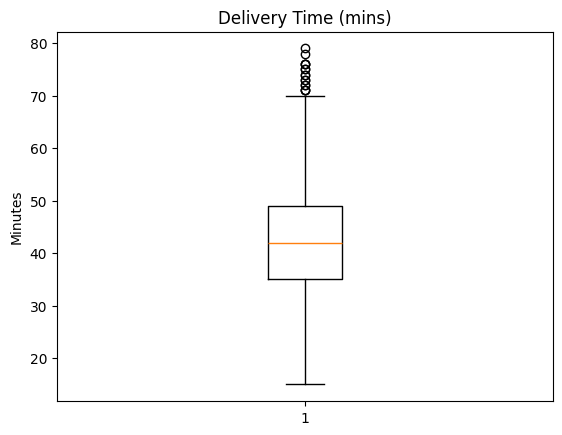

In [100]:
import matplotlib.pyplot as plt
plt.boxplot(df['delivery_time_mins'])
plt.title("Delivery Time (mins)")
plt.ylabel("Minutes")
plt.show()

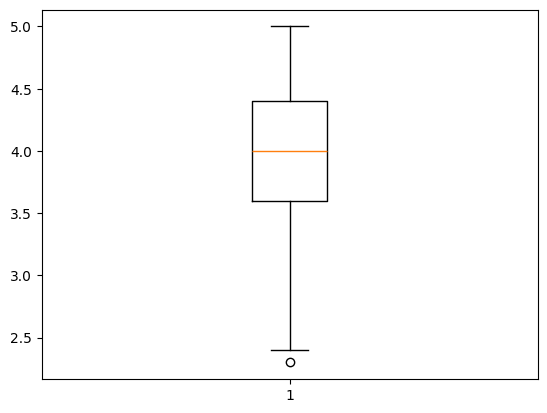

In [104]:
plt.boxplot(df['rating'].dropna())
plt.show()

In [5]:
df['rating'] = df['rating'].fillna(df['rating'].median())

In [6]:
df['time_slot'] = df['time_slot'].fillna(df['time_slot'].mode()[0])

In [7]:
df['discount_applied'] =df['discount_applied'].fillna(df['discount_applied'].median())

In [123]:
dups = df.duplicated()
len(df[dups])

50

In [126]:
df = df.drop_duplicates(subset='order_id', keep='first').reset_index(drop=True)

In [127]:
dups = df.duplicated()
len(df[dups])

0

In [129]:
city_gmv = (
    df.groupby('city')['order_value']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={'sum':'GMV', 'mean':'AOV','count':'orders'})
    .sort_values('GMV', ascending=False)
)
city_gmv

,GMV,AOV,orders
city,,,
Bangalore,180175.76,420.971402,428
Mumbai,154997.32,458.571953,338
Hyderabad,121181.27,475.220667,255
Delhi,119575.79,427.056393,280
Chennai,92432.38,466.830202,198
Kolkata,67238.89,483.733022,139
Pune,63703.87,386.084061,165
Ahmedabad,30635.85,431.490845,71
Jaipur,29695.90,430.375362,69


In [132]:
df.groupby(['category', 'time_slot']).agg(
    total_revenue = ('order_value', 'sum'),
    order_count = ('order_id', 'count'),
    avg_order = ('order_value', 'mean')
).sort_values('total_revenue', ascending=False).head(15)

total_revenue  order_count   avg_order
category     time_slot                                        
Biryani      lunch           80158.85          146  549.033219
North Indian lunch           60577.52          130  465.980923
Biryani      dinner          44261.72          105  421.540190
South Indian dinner          42934.55           93  461.661828
             lunch           42649.86           91  468.679780
North Indian dinner          40734.55          102  399.358333
Pizza        dinner          29728.36           67  443.706866
Chinese      dinner          28176.35           71  396.850000
Biryani      snacks          27874.12           71  392.593239
Pizza        lunch           27464.71           65  422.534000
Chinese      lunch           26877.81           67  401.161343
North Indian snacks          26238.37           53  495.063585
Burger       lunch           24807.46           62  400.120323
             dinner          24206.03           54  448.259815
             snacks          22595.77           37  610.696486

In [133]:
pivot = pd.pivot_table(
    df,
    values = 'order_value',
    index = 'category',
    columns = 'city',
    aggfunc = 'sum',
    fill_value = 0
)
top_cities = df.groupby('city')['order_value'].sum().nlargest(6).index
print("Revenue Pivot: Category × Top 6 Cities (in ₹)")
display(pivot[top_cities].sort_values('Bangalore', ascending=False))

Revenue Pivot: Category × Top 6 Cities (in ₹)


city,Bangalore,Mumbai,Hyderabad,Delhi,Chennai,Kolkata
category,,,,,,
Biryani,29702.85,25992.73,15477.79,26947.82,20725.04,20157.07
South Indian,29653.01,24593.75,14690.03,18390.83,8673.64,5559.67
North Indian,24513.39,34851.53,16432.60,10467.90,16395.18,7364.89
Burger,22356.30,11141.05,8996.07,13700.87,4327.73,6031.72
Desserts,14975.16,7013.73,7282.24,4662.34,6894.65,5702.42
Pizza,13462.50,7862.57,15139.40,10542.93,6561.80,5282.43
Chinese,12245.30,15501.06,10794.78,13967.62,11210.68,5109.65
Rolls & Wraps,9872.63,9541.00,8506.72,4219.38,8710.62,2048.03
Healthy,9664.74,6320.49,8831.69,4613.94,3644.55,1145.19


# new after first cell

In [20]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn. linear_model import LinearRegression, Ridge, Lasso

df = pd.read_csv('datasets//swiggy_orders.csv')
df.head()

,order_id,restaurant_name,city,category,order_value,delivery_time_mins,rating,order_date,time_slot,is_reorder,discount_applied,platform
0,101569,Sweet Truth,Hyderabad,Desserts,745.02,46.0,NaN,18-12-2024 19:51,dinner,False,97.73,iOS
1,101963,Dum Pukht,Kolkata,Biryani,114.67,69.0,3.9,26-10-2024 13:16,lunch,False,NaN,Android
2,101693,Sweet Truth,Delhi,Desserts,243.78,18.0,3.3,01-10-2024 21:54,dinner,False,58.94,Android
3,101873,Behrouz Biryani,Delhi,Biryani,274.41,35.0,3.6,30-10-2024 18:50,snacks,False,101.67,Web
4,100263,Raw Pressery Kitchen,Bangalore,Healthy,343.46,32.0,NaN,22-12-2024 12:07,lunch,False,13.51,Android


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            2050 non-null   int64  
 1   restaurant_name     2050 non-null   object 
 2   city                2050 non-null   object 
 3   category            2050 non-null   object 
 4   order_value         2050 non-null   float64
 5   delivery_time_mins  1884 non-null   float64
 6   rating              1846 non-null   float64
 7   order_date          2050 non-null   object 
 8   time_slot           1989 non-null   object 
 9   is_reorder          2050 non-null   bool   
 10  discount_applied    1133 non-null   float64
 11  platform            2050 non-null   object 
dtypes: bool(1), float64(4), int64(1), object(6)
memory usage: 178.3+ KB


In [22]:
df['order_id'].value_counts().sort_values(ascending=False).head(50)
df = df.drop_duplicates(subset='order_id')
len(df)

2000

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 2049
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            2000 non-null   int64  
 1   restaurant_name     2000 non-null   object 
 2   city                2000 non-null   object 
 3   category            2000 non-null   object 
 4   order_value         2000 non-null   float64
 5   delivery_time_mins  1840 non-null   float64
 6   rating              1800 non-null   float64
 7   order_date          2000 non-null   object 
 8   time_slot           1940 non-null   object 
 9   is_reorder          2000 non-null   bool   
 10  discount_applied    1104 non-null   float64
 11  platform            2000 non-null   object 
dtypes: bool(1), float64(4), int64(1), object(6)
memory usage: 189.5+ KB


In [24]:
for col in ['delivery_time_mins', 'rating', 'discount_applied']:
    df[col] = df[col].fillna(df[col].median())

In [27]:
df['time_slot'] = df['time_slot'].fillna(df['time_slot'].mode()[0])

In [29]:
df.columns

Index(['order_id', 'restaurant_name', 'city', 'category', 'order_value',
       'delivery_time_mins', 'rating', 'order_date', 'time_slot', 'is_reorder',
       'discount_applied', 'platform'],
      dtype='object')

In [32]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [33]:
for col in df.select_dtypes(include='object'):
    print(f"{col} has {df[col].nunique()} unique values")
    print("The unique values are: ")
    print(df[col].unique())

restaurant_name has 60 unique values
The unique values are: 
['Sweet Truth' 'Dum Pukht' 'Behrouz Biryani' 'Raw Pressery Kitchen'
 'Paradise Biryani' 'Burger King' 'Wat-A-Burger' 'Wraps N Rolls'
 'Baskin Robbins' 'Wok To Walk' 'Bawarchi' 'Chinese Box' 'Roll House'
 'Dhaba Express' 'Punjab Grill' 'Murugan Idli Shop' 'Freshmenu'
 'Empire Restaurant' 'Chai Point' 'Green Bowl' 'Saffron' 'Bay Leaf'
 'Pizza Hut' 'China Town' 'Moti Mahal' 'Barbeque Nation' 'La Folie'
 'Dominos' 'Udupi Palace' 'Mainland China' 'Saravana Bhavan'
 'The Burger Club' "Joey's Pizza" 'MTR' 'Blue Tokai' 'Burgerama'
 'Starbucks' "La Pino'z" 'Oh Calcutta' 'Chaayos' 'Theobroma' 'Nandhini'
 'Frankie Express' 'Salad Days' 'The Roll Story' 'Oven Story'
 'Kathi Roll Corner' "McDonald's" 'The Fish Shack' 'Trishna'
 'Naturals Ice Cream' 'Eatfit' 'Social' 'The Wok' 'Coastal Kitchen'
 'Hard Rock Cafe' 'Tea Trails' 'The Beer Cafe' 'The Table'
 'Smoke House Deli']
city has 12 unique values
The unique values are: 
['Hyderabad' 'Kol

In [38]:
df['restaurant_name'].value_counts().sort_values(ascending=False)

restaurant_name
Dum Pukht               85
Empire Restaurant       75
Saffron                 72
Behrouz Biryani         70
Bawarchi                66
Punjab Grill            65
Barbeque Nation         65
Paradise Biryani        63
MTR                     61
Dhaba Express           57
Mainland China          54
Udupi Palace            52
Moti Mahal              50
Nandhini                47
Wat-A-Burger            46
Saravana Bhavan         44
Murugan Idli Shop       44
Burgerama               42
China Town              40
Joey's Pizza            39
Dominos                 39
La Pino'z               38
Wok To Walk             36
The Roll Story          36
Chinese Box             33
McDonald's              32
Roll House              31
The Wok                 30
Sweet Truth             30
Oven Story              29
La Folie                29
Burger King             28
Chai Point              28
Pizza Hut               28
Salad Days              27
Baskin Robbins          26
Freshmenu   

# Rough

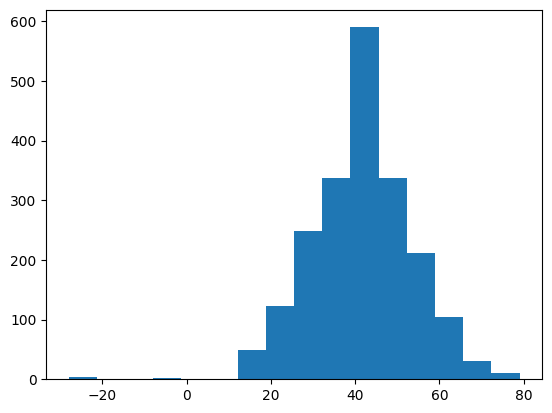

In [12]:
import matplotlib.pyplot as plt
plt.hist(df['delivery_time_mins'], bins = 16)
plt.show()

In [11]:
df['delivery_time_mins'].describe()

count    2050.000000
mean       41.595610
std        11.825636
min       -28.000000
25%        34.000000
50%        42.000000
75%        49.000000
max        79.000000
Name: delivery_time_mins, dtype: float64

In [13]:
df.groupby('city')['order_id'].count()

city
Ahmedabad     72
Bangalore    438
Chennai      203
Delhi        287
Hyderabad    265
Jaipur        71
Kochi         10
Kolkata      140
Lucknow       12
Mumbai       349
Pune         167
Surat         36
Name: order_id, dtype: int64

In [15]:
df.groupby('restaurant_name')['order_id'].count().sort_values(ascending=False).head(10)

restaurant_name
Dum Pukht            88
Empire Restaurant    76
Behrouz Biryani      72
Saffron              72
Bawarchi             68
Punjab Grill         67
Barbeque Nation      65
Paradise Biryani     65
MTR                  62
Dhaba Express        58
Name: order_id, dtype: int64

In [9]:
df.groupby('city')['delivery_time_mins'].mean().sort_values()

city
Jaipur       39.901408
Hyderabad    39.969811
Pune         40.538922
Bangalore    40.751142
Chennai      41.118227
Lucknow      41.500000
Mumbai       42.272206
Delhi        42.442509
Ahmedabad    43.194444
Kolkata      44.157143
Kochi        45.100000
Surat        47.361111
Name: delivery_time_mins, dtype: float64

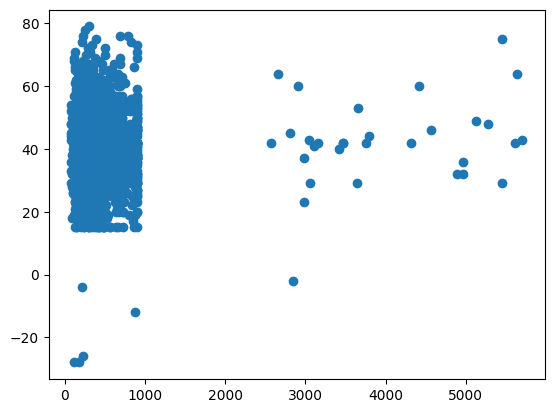

In [10]:
import matplotlib.pyplot as plt
plt.scatter(df['order_value'], df['delivery_time_mins'])
plt.show()